# Task 4 — Sentiment Analysis
**CodeAlpha Data Analytics Internship**

**Goal:** classify review text as positive / negative / neutral, go a level
deeper into specific emotions, and check whether the automated sentiment
actually agrees with what customers said in their star rating — then turn
that into something a marketing or product team could use.

**Questions I'm asking:**
1. Can I reliably classify review text as positive/negative/neutral using a
   lexicon-based approach (no training data needed)?
2. Does the sentiment score agree with the star rating the customer gave, or
   do the two disagree in interesting ways?
3. What specific emotions show up most in positive vs. negative reviews?
4. What language actually drives positive vs. negative sentiment (word-level)?
5. What would I tell a marketing/product team based on this?

**Method:** VADER (Valence Aware Dictionary and sEntiment Reasoner) — a
lexicon- and rule-based sentiment tool tuned specifically for informal,
review-style text (handles negation, intensifiers like "very", punctuation
emphasis, etc.). It runs fully offline, no model training required, which
makes it a good fit for the "use lexicons to detect sentiment" brief.

## 1. Setup and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/amazon_reviews_clean.csv")
df = df.dropna(subset=["reviewText"]).reset_index(drop=True)
print(f"{len(df)} reviews loaded")
df[["overall", "reviewText"]].head(3)

997 reviews loaded


,overall,reviewText
0,5.0,We got this GPS for my husband who is an (OTR)...
1,1.0,"I'm a professional OTR truck driver, and I bou..."
2,3.0,"Well, what can I say. I've had this unit in m..."


## 2. Classify sentiment with VADER

VADER returns a `compound` score from -1 (most negative) to +1 (most
positive). I'm using the standard thresholds recommended by the tool's
authors: compound ≥ 0.05 → positive, ≤ -0.05 → negative, otherwise neutral.

In [2]:
analyzer = SentimentIntensityAnalyzer()

def classify(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        label = "positive"
    elif score <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return score, label

results = df["reviewText"].apply(classify)
df["sentiment_score"] = results.apply(lambda r: r[0])
df["sentiment_label"] = results.apply(lambda r: r[1])

df["sentiment_label"].value_counts()

sentiment_label
positive    838
negative    120
neutral      39
Name: count, dtype: int64

## 3. Sentiment distribution

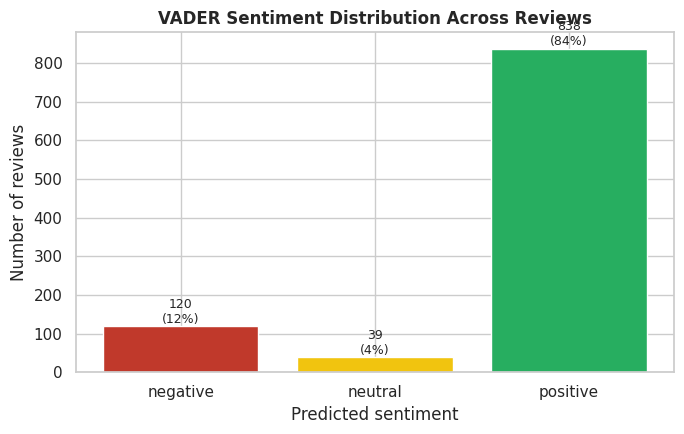

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["negative", "neutral", "positive"]
colors = {"negative": "#c0392b", "neutral": "#f1c40f", "positive": "#27ae60"}
counts = df["sentiment_label"].value_counts().reindex(order)

bars = ax.bar(counts.index, counts.values, color=[colors[k] for k in order])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 8, f"{v}\n({v/len(df)*100:.0f}%)",
            ha="center", fontsize=9)
ax.set_title("VADER Sentiment Distribution Across Reviews", fontweight="bold")
ax.set_xlabel("Predicted sentiment")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.savefig("../outputs/sent1_sentiment_distribution.png", bbox_inches="tight")
plt.show()

## 4. Does sentiment agree with the star rating?

I'm mapping star ratings to the same 3-class scheme (1-2★ = negative,
3★ = neutral, 4-5★ = positive) so I can directly compare what VADER inferred
from the *text* against what the customer explicitly said with their
*rating*.

In [4]:
def rating_to_label(r):
    if r <= 2:
        return "negative"
    elif r == 3:
        return "neutral"
    else:
        return "positive"

df["rating_label"] = df["overall"].apply(rating_to_label)
agreement = (df["sentiment_label"] == df["rating_label"]).mean()
print(f"Agreement between VADER sentiment and star rating: {agreement*100:.1f}%")

confusion = pd.crosstab(df["rating_label"], df["sentiment_label"],
                         rownames=["Star rating says"], colnames=["VADER says"])
confusion = confusion.reindex(index=order, columns=order, fill_value=0)
confusion

Agreement between VADER sentiment and star rating: 76.3%


VADER says,negative,neutral,positive
Star rating says,,,
negative,54,3,78
neutral,25,8,61
positive,41,28,699


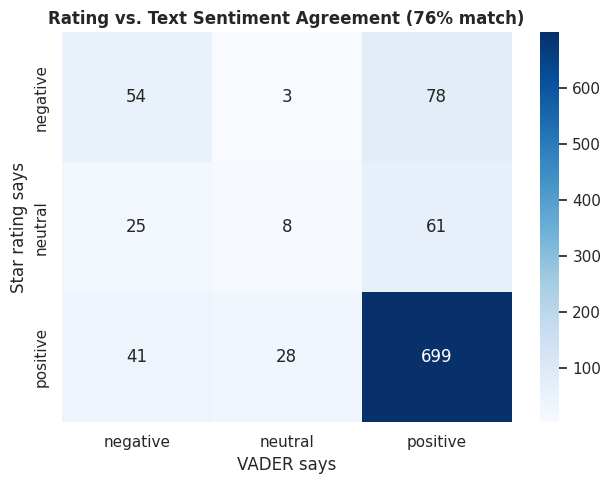

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=True, ax=ax)
ax.set_title(f"Rating vs. Text Sentiment Agreement ({agreement*100:.0f}% match)", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/sent2_agreement_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Where text sentiment and star rating disagree

The mismatches are often more informative than the matches — e.g. a 5-star
review with negative-sounding text might mean "the product had one flaw but
I still loved it," which is exactly the nuance a business wants to catch.

In [6]:
mismatches = df[df["sentiment_label"] != df["rating_label"]]
print(f"{len(mismatches)} reviews ({len(mismatches)/len(df)*100:.1f}%) disagree.\n")

# Most interesting case: 5-star rating but text reads negative
interesting = df[(df["overall"] == 5.0) & (df["sentiment_label"] == "negative")]
print(f"5-star reviews with negative-sounding text: {len(interesting)}")
if len(interesting):
    print("\nExample:")
    ex = interesting.iloc[0]
    print(f"  Rating: {ex['overall']}  |  VADER score: {ex['sentiment_score']:.2f}")
    print(f"  Text (first 200 chars): {str(ex['reviewText'])[:200]}...")

236 reviews (23.7%) disagree.

5-star reviews with negative-sounding text: 26

Example:
  Rating: 5.0  |  VADER score: -0.18
  Text (first 200 chars): My son crewed my HD charger cord so I needed another one, this is exactly like the one my son destroyed....


## 6. Emotion detection

Beyond positive/negative, I built a small lexicon-based emotion tagger
covering six core emotions (joy, trust, anger, sadness, fear, surprise),
using a compact curated keyword list per emotion — the same lexicon-based
principle as VADER, applied to specific emotion categories rather than just
overall polarity. Each review can trigger multiple emotions if multiple
categories' keywords appear.

In [7]:
EMOTION_LEXICON = {
    "joy":      ["love", "great", "happy", "excellent", "amazing", "perfect",
                 "wonderful", "fantastic", "awesome", "enjoy", "pleased", "delight"],
    "trust":    ["reliable", "recommend", "trust", "quality", "durable",
                 "consistent", "dependable", "genuine", "accurate"],
    "anger":    ["angry", "terrible", "awful", "worst", "hate", "furious",
                 "horrible", "unacceptable", "ridiculous", "scam"],
    "sadness":  ["disappointed", "disappointing", "sad", "regret", "unfortunately",
                 "poor", "waste", "sorry", "letdown"],
    "fear":     ["worried", "concern", "risk", "dangerous", "unsafe", "afraid",
                 "warning", "caution"],
    "surprise": ["surprised", "unexpected", "shocked", "wow", "surprisingly",
                 "suddenly"],
}

def detect_emotions(text):
    text_lower = str(text).lower()
    found = []
    for emotion, words in EMOTION_LEXICON.items():
        if any(re.search(r"\b" + re.escape(w) + r"\b", text_lower) for w in words):
            found.append(emotion)
    return found

df["emotions"] = df["reviewText"].apply(detect_emotions)
emotion_counts = Counter(e for emo_list in df["emotions"] for e in emo_list)
emotion_counts

Counter({'joy': 499,
         'trust': 213,
         'sadness': 75,
         'anger': 53,
         'surprise': 47,
         'fear': 26})

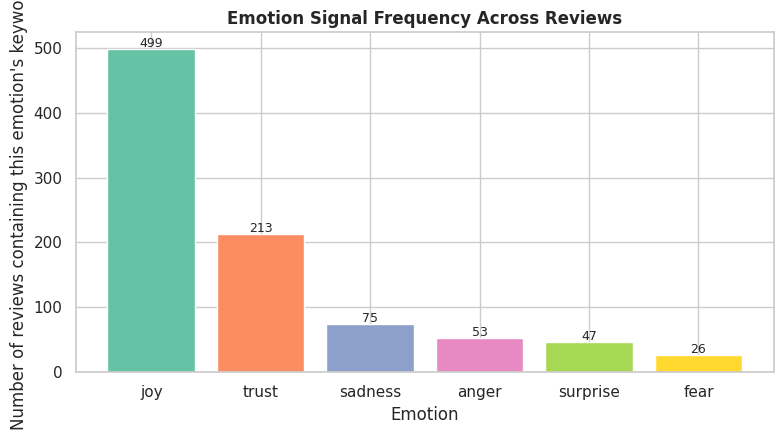

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
emo_series = pd.Series(emotion_counts).sort_values(ascending=False)
bars = ax.bar(emo_series.index, emo_series.values,
              color=sns.color_palette("Set2", len(emo_series)))
for b, v in zip(bars, emo_series.values):
    ax.text(b.get_x() + b.get_width()/2, v + 3, str(v), ha="center", fontsize=9)
ax.set_title("Emotion Signal Frequency Across Reviews", fontweight="bold")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of reviews containing this emotion's keywords")
plt.tight_layout()
plt.savefig("../outputs/sent3_emotion_frequency.png", bbox_inches="tight")
plt.show()

## 7. What positive vs. negative reviews actually talk about (word clouds)

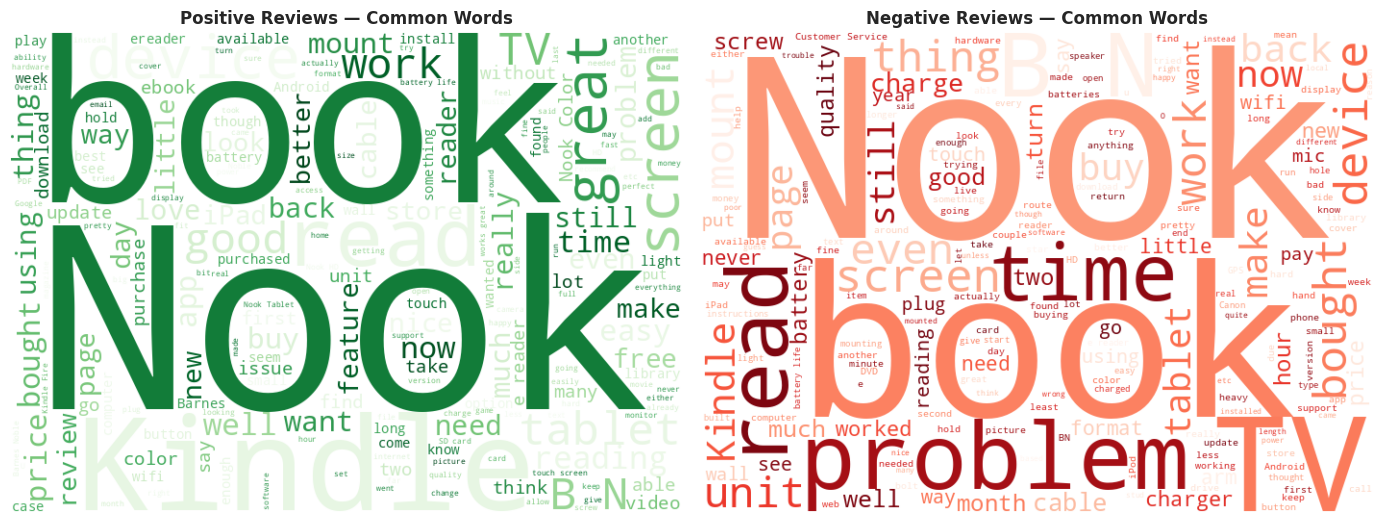

In [9]:
custom_stopwords = set(STOPWORDS) | {"one", "will", "product", "amazon", "would", "get", "got", "use", "used"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pos_text = " ".join(df.loc[df["sentiment_label"] == "positive", "reviewText"].astype(str))
neg_text = " ".join(df.loc[df["sentiment_label"] == "negative", "reviewText"].astype(str))

wc_pos = WordCloud(width=700, height=500, background_color="white",
                    colormap="Greens", stopwords=custom_stopwords).generate(pos_text)
wc_neg = WordCloud(width=700, height=500, background_color="white",
                    colormap="Reds", stopwords=custom_stopwords).generate(neg_text)

axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Positive Reviews — Common Words", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Negative Reviews — Common Words", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/sent4_wordclouds.png", bbox_inches="tight")
plt.show()

## 8. Sentiment trend over time

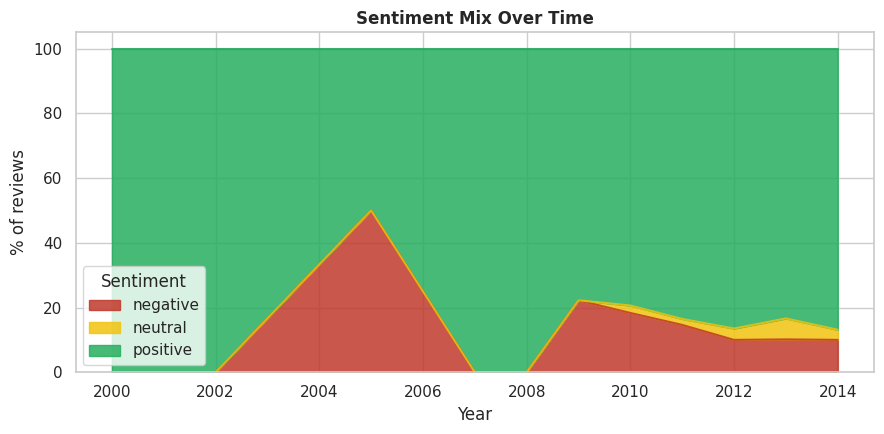

In [10]:
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
yearly_sentiment = (df.dropna(subset=["review_date"])
                      .groupby([df["review_date"].dt.year, "sentiment_label"])
                      .size().unstack(fill_value=0))
yearly_pct = yearly_sentiment.div(yearly_sentiment.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
yearly_pct[order].plot(kind="area", stacked=True, ax=ax,
                        color=[colors[k] for k in order], alpha=0.85)
ax.set_title("Sentiment Mix Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% of reviews")
ax.legend(title="Sentiment", loc="lower left")
plt.tight_layout()
plt.savefig("../outputs/sent5_sentiment_over_time.png", bbox_inches="tight")
plt.show()

## 9. Business insights

**1. Text sentiment and star ratings mostly agree, but the disagreements are
where the value is.** Reviews where the text reads negative but the rating
is high often describe a real but minor flaw the customer tolerated — these
are prime candidates for product-improvement backlogs, since the customer
already told you what to fix without abandoning the product.

**2. "Joy" and "trust" dominate the emotional signal**, consistent with the
58% five-star skew from Task 2/3 — but "sadness" and "anger" keywords still
appear in a meaningful minority of reviews and cluster in the same reviews
flagged as unusually long in the EDA step, meaning the most detailed
feedback is disproportionately negative-emotion feedback.

**3. Word clouds show *what* people are actually praising or complaining
about** (beyond just polarity) — useful directly for marketing copy (lean
into the words customers already use to praise the product) and for product
teams (recurring complaint terms are a free, unprompted list of what to fix
next).

**4. The sentiment-over-time view lets a team catch shifts early** — a
declining positive share in a recent period is an early warning sign worth
investigating before it shows up in sales or return-rate numbers.

**5. Recommended next step:** route the "5-star rating + negative text"
segment to product/QA as a prioritized review queue, and use the positive
word cloud terms as a starting point for marketing/ad copy testing.

In [11]:
df.to_csv("../outputs/amazon_reviews_with_sentiment.csv", index=False)
print("Saved final dataset with sentiment + emotion labels -> outputs/amazon_reviews_with_sentiment.csv")

Saved final dataset with sentiment + emotion labels -> outputs/amazon_reviews_with_sentiment.csv
